In [6]:
import h5py
import yaml
import pickle
import numpy as np
import matplotlib.pyplot as plt
from scipy.interpolate import griddata

In [14]:
parentdir = '/scratch/bstanisl/pvade/turb_inflow/'
casepath = 'y20m_turbinflow_duramat_validation/'

tilts = [40.0]

output_dir=parentdir+'output/'+casepath

# read input parameters
with open(output_dir+'input_params.yaml', 'r') as file:
    params = yaml.safe_load(file)

print('tracker_angle = {} m/s'.format(params['pv_array']['tracker_angle']))
dt = params['solver']['dt']

save_pkl_name = f'duramatval_tracker_angle_{params['pv_array']['tracker_angle']}.pkl'

# read solution_fluid.h5
fname = output_dir + 'solution/solution_fluid.h5'

with h5py.File(fname, "r") as f:
    print("Reading from " + fname)
    
    # Mesh coordinates  ===============
    coords = f["Mesh/fluid_mesh.xdmf/geometry"][:]
    print("Coords shape:", coords.shape)  # Should be (538, 3) or (538, 2)
    
    # Velocity ===============
    velocity_group = f["Function/velocity "]
    
    # Sort dataset keys numerically
    keys = sorted(velocity_group.keys(), key=lambda k: float(k.replace("_", ".")))
    
    # Load all time steps into list
    data_list = [velocity_group[k][:] for k in keys]
    rawdata = np.stack(data_list)  # Shape: (n_timesteps, n_points, 3)

print("Combined velocity shape:", rawdata.shape)  # e.g. (100, 5000, 3)

tracker_angle = 40.0 m/s
Reading from /scratch/bstanisl/pvade/turb_inflow/output/y20m_turbinflow_duramat_validation/solution/solution_fluid.h5
Coords shape: (371287, 3)
Combined velocity shape: (2501, 371287, 3)


Estimated grid points: nx=150, ny=50, nz=50
Check: nx * ny * nz = 375000


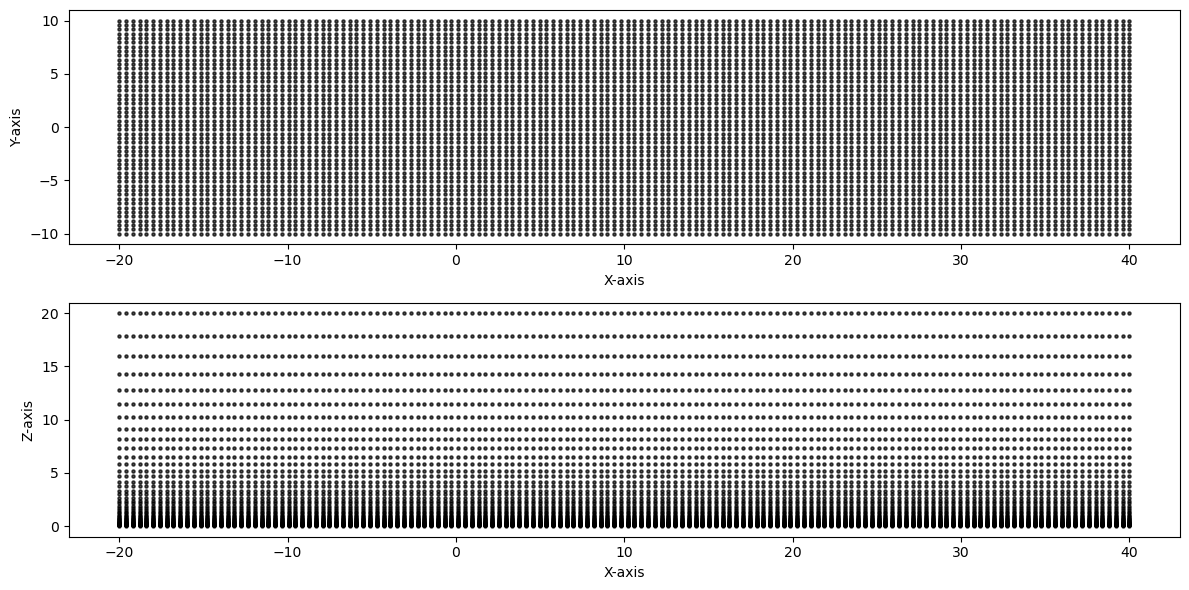

In [11]:
# compute approximate nx, ny, nz
# assuming same domain shape           
N = coords.shape[0]
Lx = params['domain']['x_max']-params['domain']['x_min']
Lz = params['domain']['z_max']-params['domain']['z_min']
Ly = params['domain']['y_max']-params['domain']['y_min']

volume = Lx * Ly * Lz
s = (N / volume) ** (1/3)

nx = round(s * Lx)
ny = round(s * Ly)
nz = round(s * Lz)

print(f"Estimated grid points: nx={nx}, ny={ny}, nz={nz}")
print(f"Check: nx * ny * nz = {nx * ny * nz}")

# Interpolate to regular grid
alldata = {}

nt, npoints, ncomp = rawdata.shape

# Create regular grid to interpolate onto
xi = np.linspace(coords[:, 0].min(), coords[:, 0].max(), nx)
yi = np.linspace(coords[:, 1].min(), coords[:, 1].max(), ny)
# zi = np.linspace(coords[:, 2].min(), coords[:, 2].max(), nz)
mask = coords[:, 2] > 0.0
log_spaced = np.logspace(np.log10(coords[:, 2][mask].min()), np.log10(coords[:, 2].max()), nz-1)
zi = np.concatenate(([0.0], log_spaced))
X, Y, Z = np.meshgrid(xi, yi, zi, indexing='ij')

# VISUALIZE: Extract a slice for the X-Y plane (e.g., at a fixed Z index)
z_index = 0  # For the X-Y slice at a specific Z-value
xy_slice = Z == Z[0, 0, z_index]  # Create a mask for the slice

# Extract a slice for the X-Z plane (e.g., at a fixed Y index)
y_index = 0  # For the X-Z slice at a specific Y-value
xz_slice = Y == Y[0, y_index, 0]  # Create a mask for the slice

# Create the plot
fig, axes = plt.subplots(2, 1, figsize=(12, 6))

# Plot the X-Y slice
axes[0].scatter(X[xy_slice], Y[xy_slice], c='k', alpha=0.7, s=5)
# axes[0].set_title("X-Y Slice")
axes[0].set_xlabel("X-axis")
axes[0].set_ylabel("Y-axis")

# Plot the X-Z slice
axes[1].scatter(X[xz_slice], Z[xz_slice], c='k', alpha=0.7, s=5)
# axes[1].set_title("X-Z Slice")
axes[1].set_xlabel("X-axis")
axes[1].set_ylabel("Z-axis")

plt.tight_layout()
plt.show()

In [19]:
# Interpolate to regular grid
alldata = {}

alldata['u'] = np.full((nt, nx, ny, nz), np.nan, dtype=float) #np.empty((nt, nx, ny, nz))
alldata['v'] = np.full((nt, nx, ny, nz), np.nan, dtype=float) #np.empty((nt, nx, ny, nz))
alldata['w'] = np.full((nt, nx, ny, nz), np.nan, dtype=float) #np.empty((nt, nx, ny, nz))
# alldata['T'] = np.empty((nt, nx, ny))

# Interpolate
for t in np.arange(0, 10): # nt): #range(nt):
    # if t % 100 == 0:
    print('nt = {}'.format(t))
    alldata['u'][t, :, :, :] = griddata(coords, rawdata[t, :, 0], (X, Y, Z), method='nearest')
    alldata['v'][t, :, :, :] = griddata(coords, rawdata[t, :, 1], (X, Y, Z), method='nearest')
    alldata['w'][t, :, :, :] = griddata(coords, rawdata[t, :, 2], (X, Y, Z), method='nearest')

del rawdata

# Save X,Y,Z
alldata['X'] = X
alldata['Y'] = Y
alldata['Z'] = Z

# Saving interpolated data to pickle file
with open(parentdir+'interp_data/timeseries_data/'+save_pkl_name, 'wb') as f:
    pickle.dump(alldata, f)


nt = 0
nt = 1
nt = 2
nt = 3
nt = 4
nt = 5
nt = 6
nt = 7
nt = 8
nt = 9


In [22]:
# read velocity data
readdata = {}
coords = {}
    
for j, tilt in enumerate(tilts):
    readdata[tilt] = {}
    coords[tilt] = {}

    pkl_fname = f'duramatval_tracker_angle_{tilt}.pkl'
    pkl_path = parentdir+'interp_data/timeseries_data/'+save_pkl_name

    print('reading from', pkl_path)

    try:
        with open(pkl_path, 'rb') as f:
            # try:
            readrawdata = pickle.load(f)
                
            # print(rawdata[winddir][tilt][case].keys())
            readdata[tilt]['u'] = readrawdata['u']
            readdata[tilt]['v'] = readrawdata['v']
            readdata[tilt]['w'] = readrawdata['w']
            print('vel data nx, ny, nz = ', np.shape(readdata[tilt]['u']))
    except Exception as e:
        print(f"Error loading pickle file: {e}")

# i think coords are only different for each tilt angle
if 'X' in readrawdata.keys():
    tmpX = readrawdata['X']
    print('coord nx, ny, nz = ', np.shape(tmpX))
    del tmpX

    coords[tilt]['X'] = readrawdata['X']
    coords[tilt]['Y'] = readrawdata['Y']
    coords[tilt]['Z'] = readrawdata['Z']
                        
del readrawdata

ndim = len(np.shape(readdata[tilt]['u']))

reading from /scratch/bstanisl/pvade/turb_inflow/interp_data/timeseries_data/duramatval_tracker_angle_40.0.pkl
vel data nx, ny, nz =  (2501, 150, 50, 50)
coord nx, ny, nz =  (150, 50, 50)


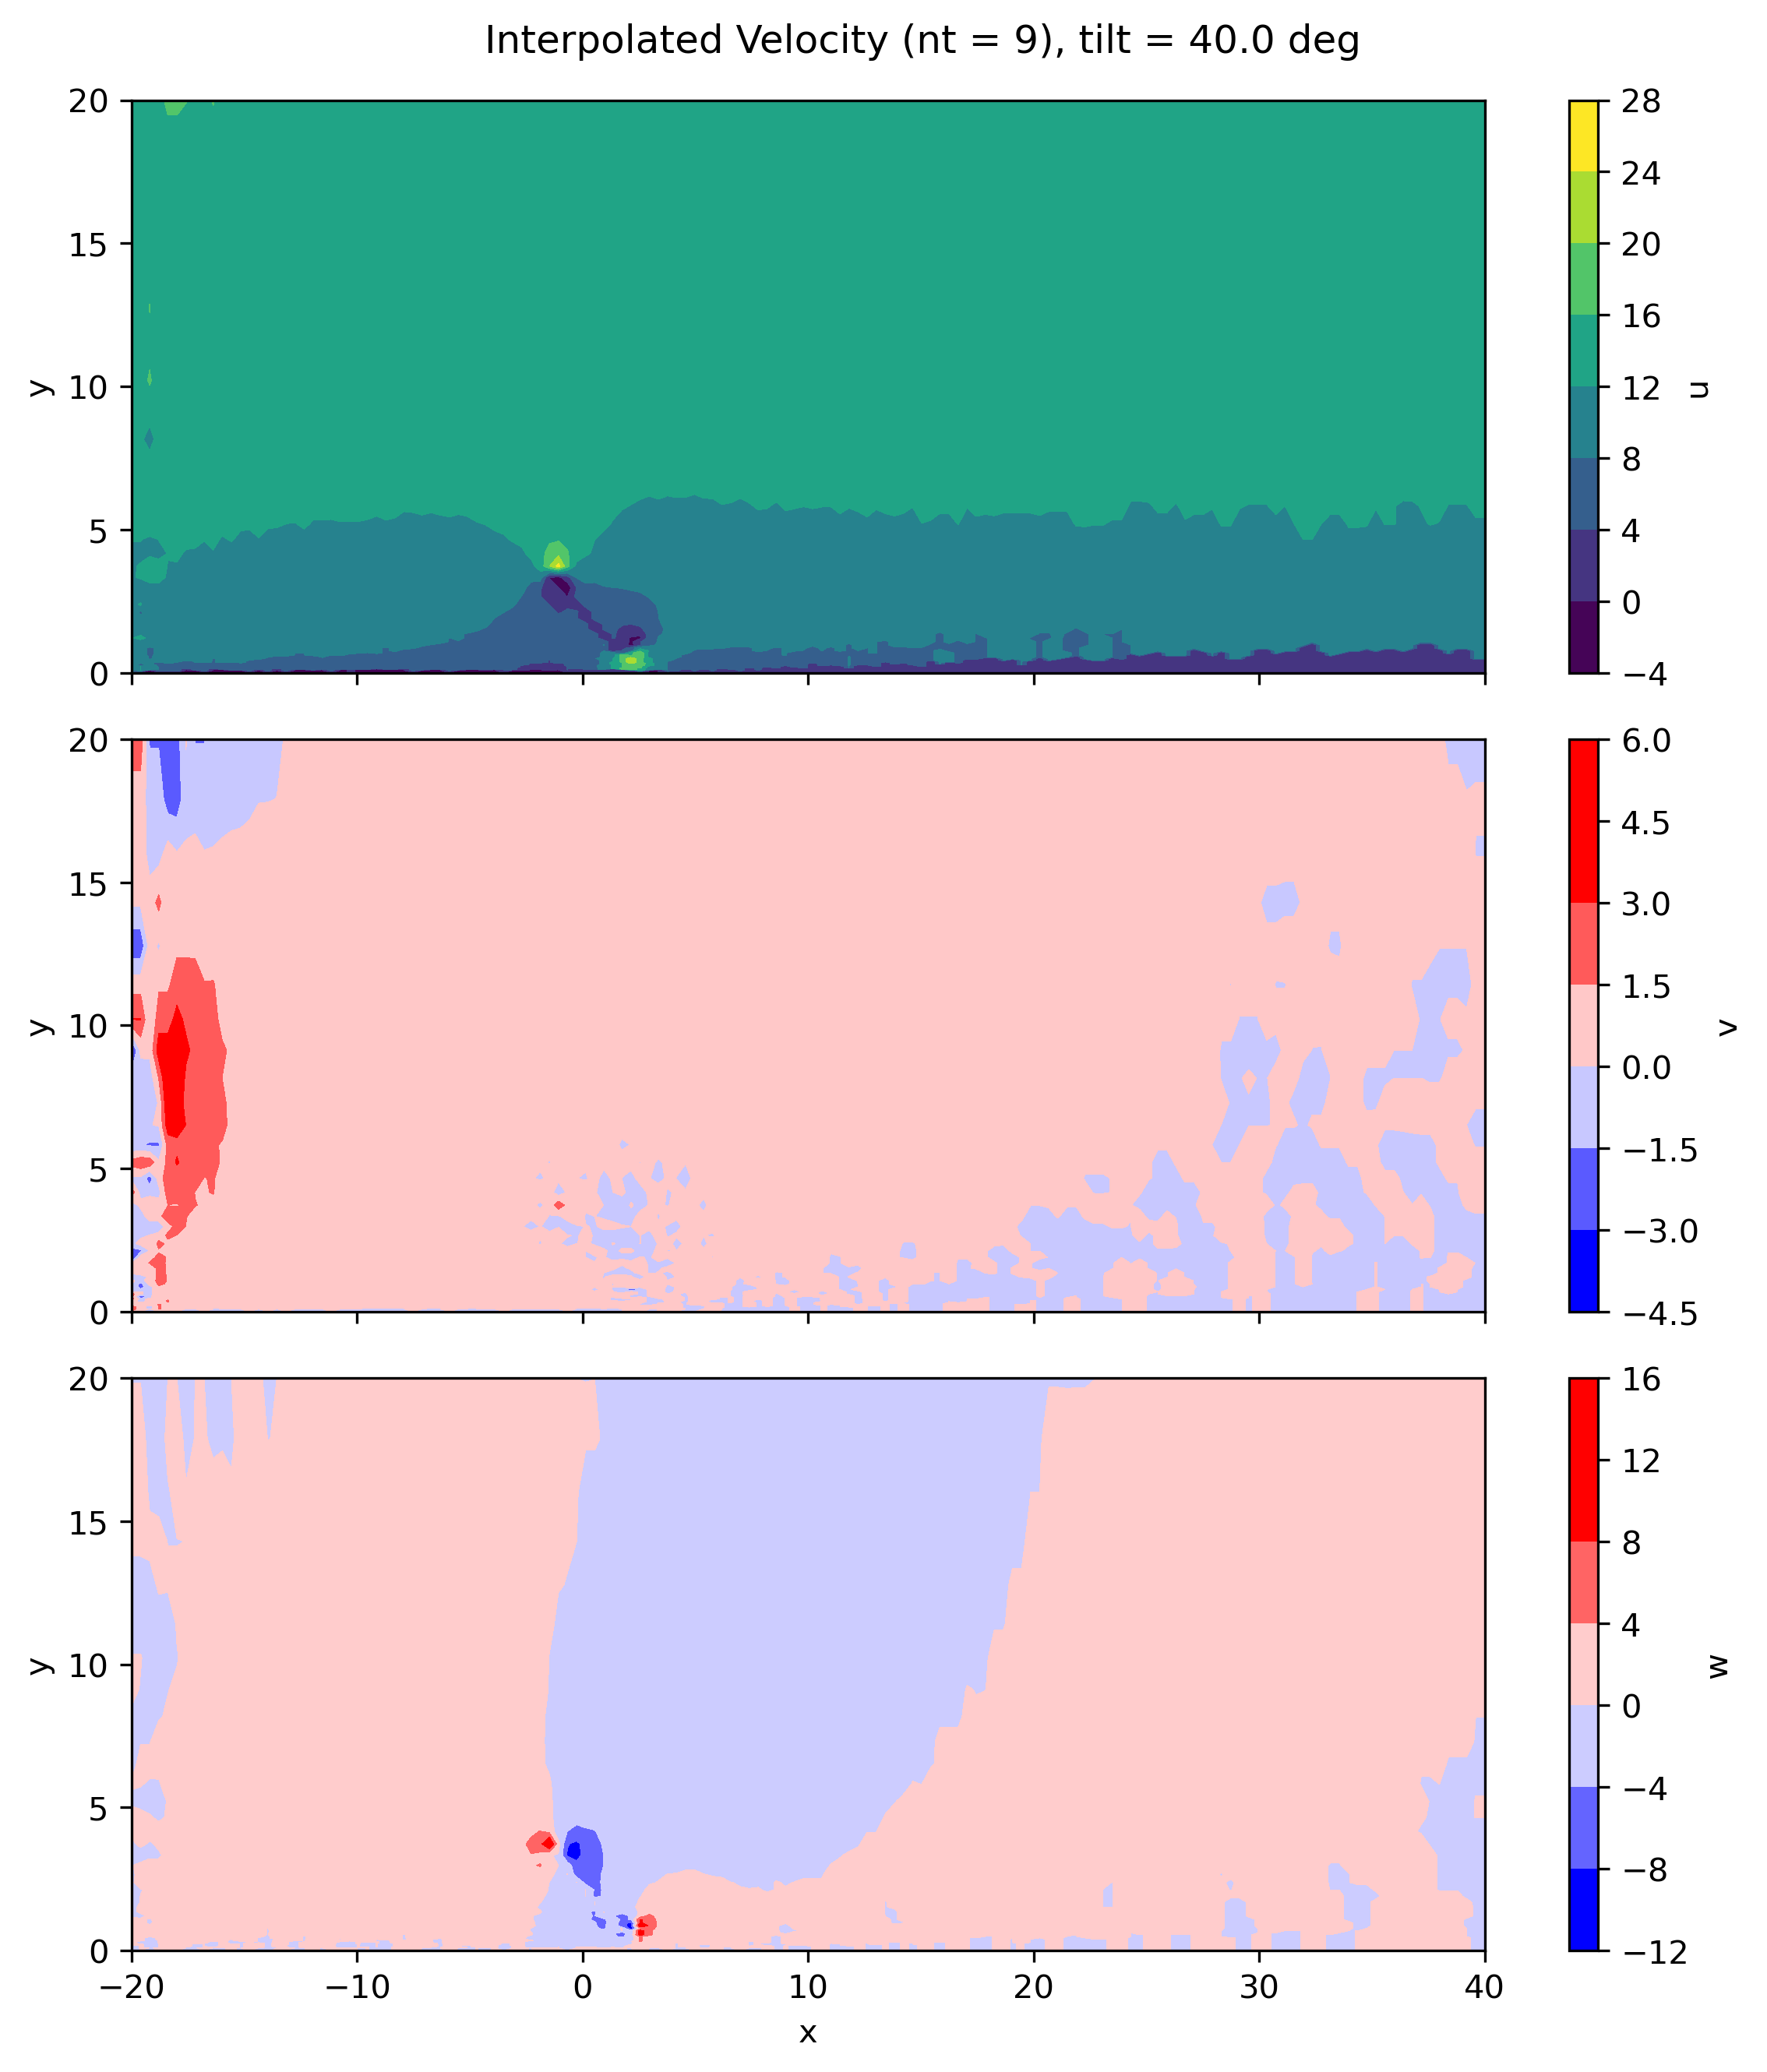

In [51]:
# Plot instantaneous fields with pcolormesh or imshow
t = 9 #200
yslice = int(ny/2)

# for case in casenames:
# case = 'thermal_false'
# fig, axs = plt.subplots(2, 1, figsize=[8,6], sharex=True, dpi=300)
fig, axs = plt.subplots(3, 1, figsize=[8,9], sharex=True, dpi=300)

fig.suptitle(f"Interpolated Velocity (nt = {t}), tilt = {tilt} deg")

for comp,ax in zip(readdata[tilt].keys(), axs.ravel()):
    pltdata = readdata[tilt][comp][t, :, yslice, :]
    minval = np.min(pltdata)
    maxval = np.max(pltdata)
    if 'u' in comp:
        cmap = 'viridis'
    else:
        limit = np.max([abs(minval),abs(maxval)])
        minval = -0.7*limit
        maxval = 0.7*limit
        cmap = 'bwr'
    # pcm = ax.pcolormesh(X[:,yslice,:], Z[:,yslice,:], readdata[comp][t, :, yslice, :], shading='auto', cmap='viridis')
    pcm = ax.contourf(X[:,yslice,:], Z[:,yslice,:], pltdata, vmin=minval, vmax=maxval, cmap=cmap)
    plt.colorbar(pcm, ax=ax, label=comp)
    ax.set_ylabel("y")
axs[-1].set_xlabel("x")
plt.tight_layout()

In [34]:
np.shape(readdata[tilt][comp])

(2501, 150, 50, 50)

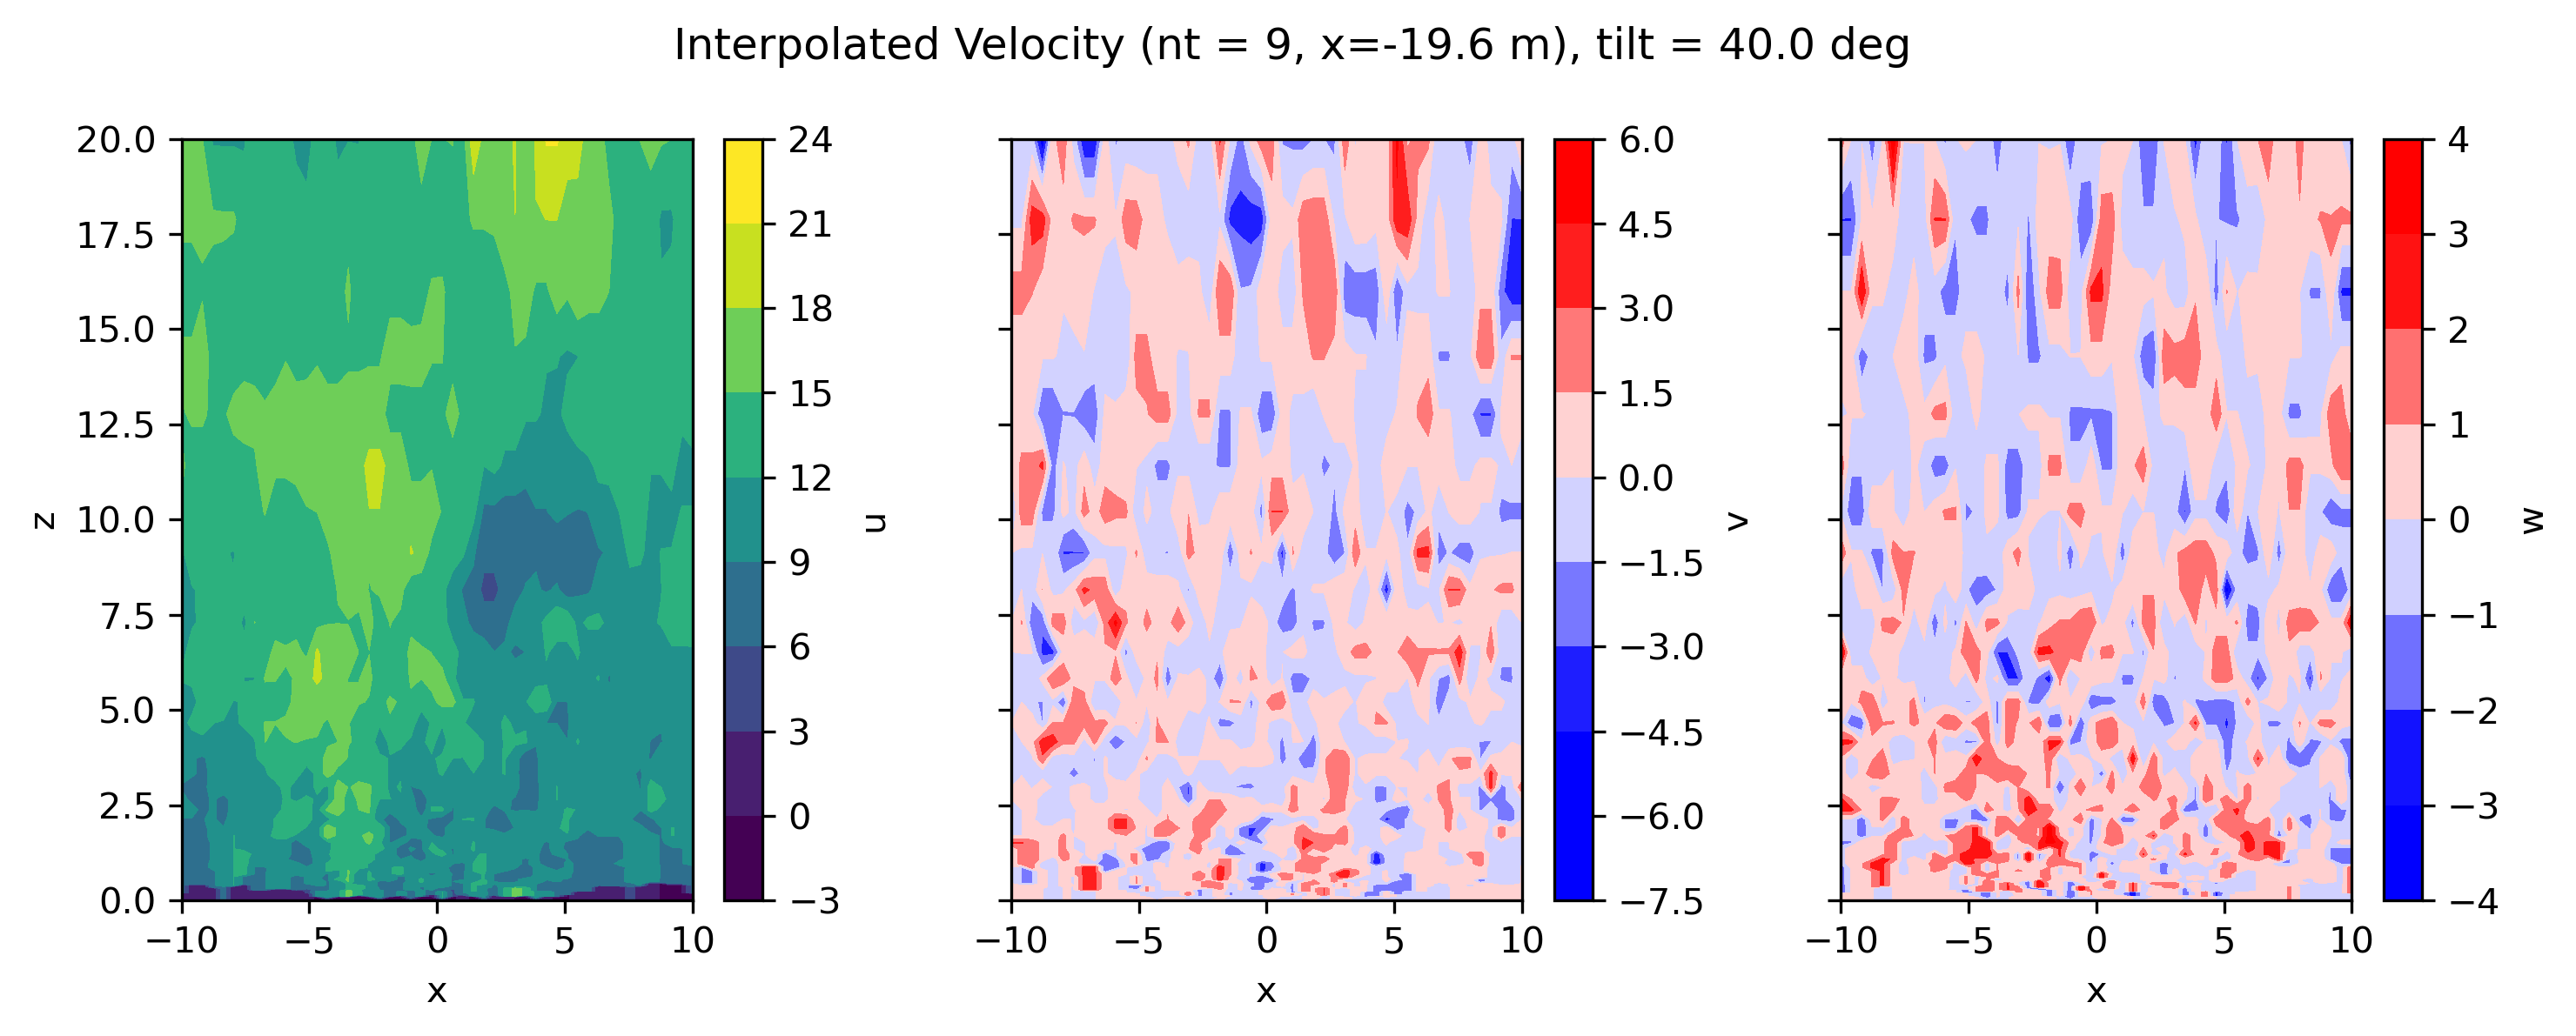

In [52]:
# Plot instantaneous fields with pcolormesh or imshow
t = 9 #200
# target = -12.36
xs = [-19.6] #, -12.36, -5.0, -1.0]

for x_val in xs:
    xslice = np.argmin(np.abs(xi - x_val))
    # xslice = 1

    fig, axs = plt.subplots(1, 3, figsize=[10,4], sharey=True, dpi=300)
    
    fig.suptitle(f"Interpolated Velocity (nt = {t}, x={xi[xslice]:.1f} m), tilt = {tilt} deg")
    
    for comp,ax in zip(readdata[tilt].keys(), axs.ravel()): 
        pltdata = readdata[tilt][comp][t, xslice, :, :]
        minval = np.min(pltdata)
        maxval = np.max(pltdata)
        if 'u' in comp:
            cmap = 'viridis'
        else:
            limit = np.max([abs(minval),abs(maxval)])
            minval = -0.7*limit
            maxval = 0.7*limit
            cmap = 'bwr'
        # pcm = ax.pcolormesh(X[:,yslice,:], Z[:,yslice,:], readdata[comp][t, :, yslice, :], shading='auto', cmap='viridis')
        pcm = ax.contourf(Y[xslice,:,:], Z[xslice,:,:], pltdata, vmin=minval, vmax=maxval, cmap=cmap)
        plt.colorbar(pcm, ax=ax, label=comp)
        ax.set_xlabel("x")
    axs[0].set_ylabel("z")
    plt.tight_layout()